# Causal Impacts of ENSO on Northern South American (NSA) Vegetation
**Granger-PCA analysis of ENSO → NDVI teleconnections**

This notebook is a self-contained, publication-ready pipeline:
1. Configuration
2. Data loading, cleaning and preprocessing
3. Exploratory analysis (mean time-series, trends, seasonal ENSO phasing)
4. GPCA fitting across candidate lags
5. Optimal lag selection (highest EVR with p < threshold)
6. Results: spatial weight maps, summary table
7. μ regularisation trade-off (train vs test)
8. Final composite figure (Nature Communications)


## 1 — Imports

In [ ]:
# Standard library
import os
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('../')

# Data
import numpy as np
import pandas as pd
import xarray as xr
from scipy.signal import detrend
from scipy.stats import pearsonr

# Visualisation
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import rasterio

# ML / stats
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score
from tqdm import tqdm

# Local package — GPCA + teleconnection baselines
from models.granger_pca import GrangerPCA
from models.teleconnection_models import (
    RegressionAnalysis, CompositeAnalysis,
    CanonicalCorrelationAnalysis, SpatialAveraging, PrincipalComponents,
)
from src.granger_causality_test import test_granger_causality

# Project utilities (utils.py in this directory)
from src.utils_v2 import (
    generate_past_data, explained_variance_ratio_fast,
    get_weights, find_optimal_mu_idx,
    build_lonlat_grid, reconstruct_2d_field,
    sample_koppen_classes, build_koppen_dataframe,
    build_results_table, KOPPEN_NAMES,
)
from src.plot_weights import plot_weight_maps

np.random.seed(1234)


## 2 — Configuration
All experiment parameters are centralised here.

In [20]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR    = "../data"
NDVI_FILE   = f"/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/NORTHERN_SOUTH_AMERICA/NDVI/X.tsv"
ENSO_FILE   = f"/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/NORTHERN_SOUTH_AMERICA/NDVI/Y.tsv"
MASK_FILE   = f"/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/NORTHERN_SOUTH_AMERICA/NDVI/na_mask.nc"
TIME_FILE   = "../data/time.csv"
KOPPEN_TIF  = f"{DATA_DIR}/koppen_geiger_0p1.tif"

# ── Study region ───────────────────────────────────────────────────────────
EXTENT = [-83, -60, -14, 14]           # [lon_min, lon_max, lat_min, lat_max]

# ── Preprocessing ──────────────────────────────────────────────────────────
N_YEARS          = 20                  # total years in dataset
N_MONTHS         = 23                  # months per climatological cycle
TRAIN_RATIO      = 0.80               # fraction for training
N_PCA_COMPONENTS = 100                # PCA pre-reduction dimensionality

# ── GPCA hyperparameters ───────────────────────────────────────────────────
CANDIDATE_LAGS   = [1, 2, 3, 4]             # lags (months) to evaluate
ALPHA_RIDGE      = np.logspace(-5, 20, 100)
MU_GRID          = np.logspace(-8, 0, 40)
ALPHA_STAB       = 1e-4               # stabilisation parameter
N_BLOCKS_CV      = 5                  # number of blocks for block-CV residuals
GC_TEST_LEVEL    = 1e-2               # significance level for GC during mu selection

# ── Results ─────────────────────────────────────────────────────────────────
PVALUE_THRESHOLD = 0.05               # threshold for reporting Granger causality
CORR_SIG_ALPHA   = 0.05               # pixel-wise correlation significance


## 3 — Data Loading, Cleaning & Preprocessing

In [5]:
# ── Load raw arrays ─────────────────────────────────────────────────────────
ndvi        = np.genfromtxt(NDVI_FILE)
oscillation = np.genfromtxt(ENSO_FILE)
mask_ds     = xr.open_dataset(MASK_FILE)
na_mask     = mask_ds["na_mask"].values
easting     = mask_ds.easting.values
northing    = mask_ds.northing.values

# ── Datetime index ─────────────────────────────────────────────────────────
time_df = pd.read_csv(TIME_FILE, index_col=0, parse_dates=True)
dates   = pd.to_datetime(time_df.iloc[:, 0])

print(f"NDVI shape      : {ndvi.shape}")
print(f"Oscillation shape: {oscillation.shape}")
print(f"na_mask shape   : {na_mask.shape}")
print(f"Time range      : {dates.iloc[0].date()} → {dates.iloc[-1].date()}")


NDVI shape      : (460, 9421)
Oscillation shape: (460,)
na_mask shape   : (142, 89)
Time range      : 2001-01-01 → 2020-12-18


In [6]:
# ── Seasonal anomalies ──────────────────────────────────────────────────────
seasonalities   = ndvi.reshape(N_YEARS, N_MONTHS, -1).mean(axis=0)
ndvi_anomalies  = ndvi.reshape(N_YEARS, N_MONTHS, -1) - seasonalities
anomalies       = ndvi_anomalies.reshape(N_YEARS * N_MONTHS, -1)

# ── Linear detrending ───────────────────────────────────────────────────────
anomalies   = detrend(anomalies,   axis=0, type="linear")
oscillation = detrend(oscillation, axis=0, type="linear")

# ── Standardise NDVI ────────────────────────────────────────────────────────
anomalies = (anomalies - anomalies.mean(axis=0)) / anomalies.std(axis=0)

# ── Train / test split (chronological) ─────────────────────────────────────
n          = len(anomalies)
train_size = int(n * TRAIN_RATIO)

anomalies_train   = anomalies[:train_size]
anomalies_test    = anomalies[train_size:]
oscillation_train = oscillation[:train_size]
oscillation_test  = oscillation[train_size:]

print(f"Train: {train_size} months  |  Test: {n - train_size} months")


Train: 368 months  |  Test: 92 months


## 4 — Exploratory Analysis
### 4.1 Mean NDVI anomaly time-series vs ENSO index


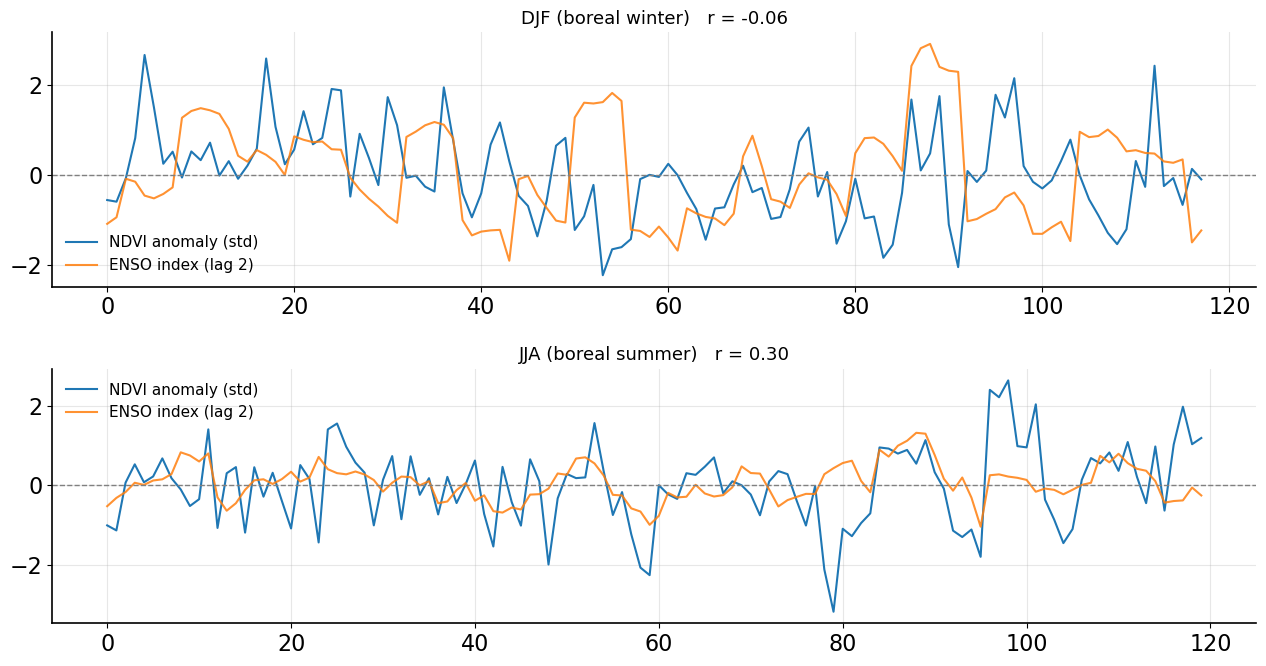

In [8]:
mean_anom = anomalies.mean(axis=1)

# Align with a lag-2 offset for DJF/JJA inspection
mean_anom_lag = mean_anom[2:]
enso_lag      = oscillation[:-2]
dates_lag     = dates[2:]

df_explore = pd.DataFrame(
    {"mean_anom": mean_anom_lag, "oscillation": enso_lag},
    index=dates_lag,
)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

for ax, season, months, title in zip(
    axes,
    ["DJF", "JJA"],
    [[12, 1, 2], [6, 7, 8]],
    ["DJF (boreal winter)", "JJA (boreal summer)"],
):
    sub = df_explore[df_explore.index.month.isin(months)]
    ndvi_std = sub["mean_anom"] / sub["mean_anom"].std()
    r = np.corrcoef(sub["mean_anom"], sub["oscillation"])[0, 1]
    ax.plot(ndvi_std.to_numpy(), lw=1.5, label="NDVI anomaly (std)")
    ax.plot(sub["oscillation"].to_numpy(), lw=1.5, alpha=0.85, label="ENSO index (lag 2)")
    ax.axhline(0, ls="--", lw=1, color="gray")
    ax.set_title(f"{title}   r = {r:.2f}", fontsize=13)
    ax.legend(frameon=False, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/mean_timeseries_NDVI_ENSO.pdf", bbox_inches="tight")
plt.show()


### 4.2 Seasonal phasing of ENSO relative to NSA wet seasons

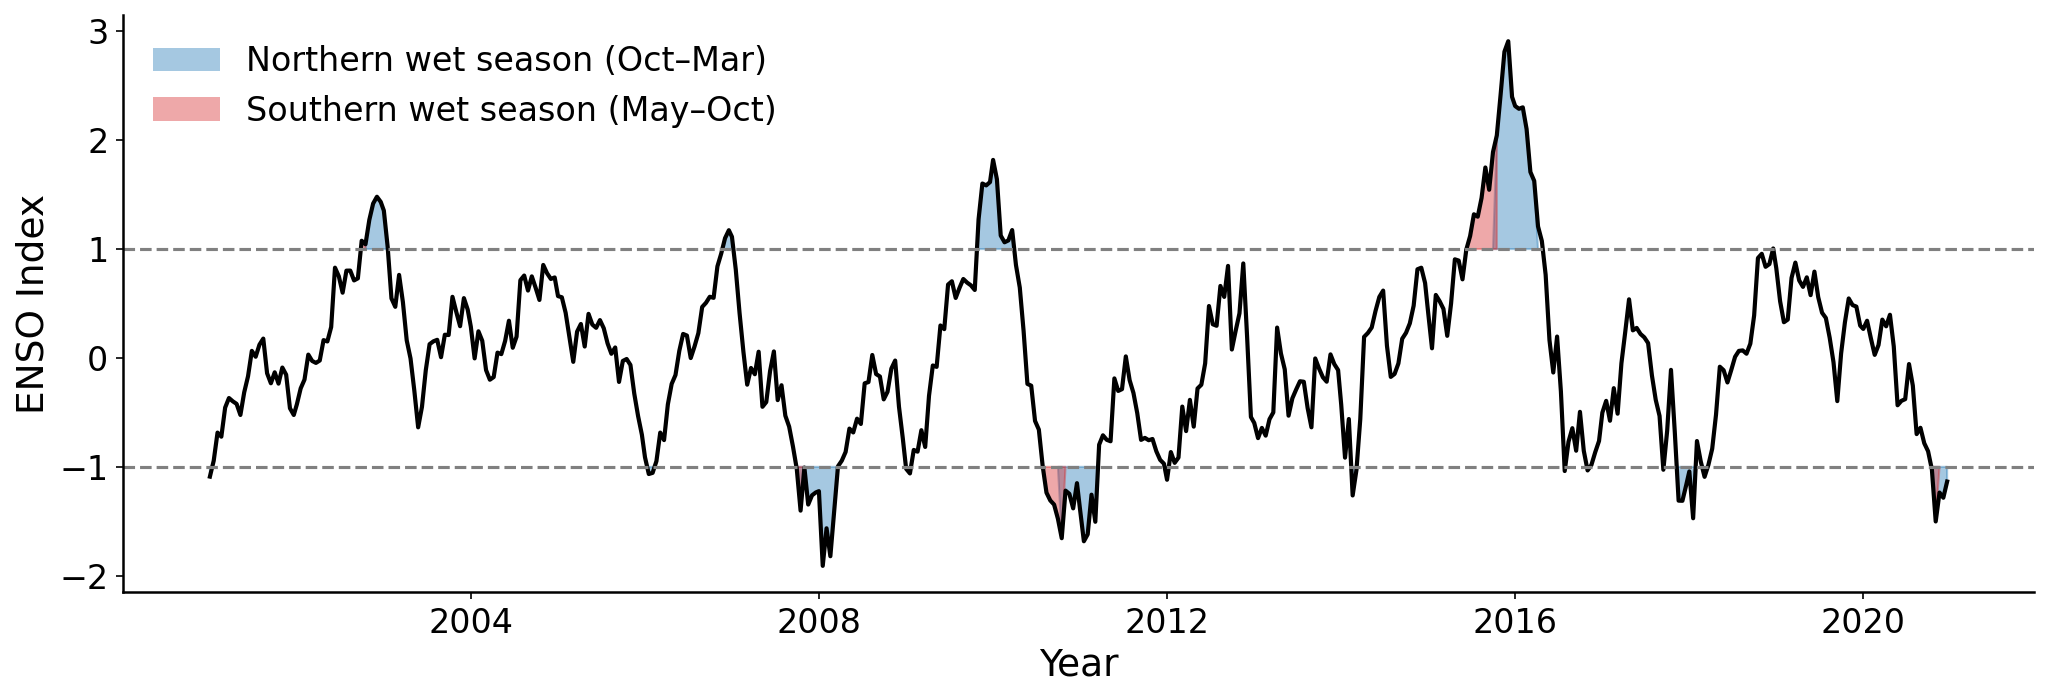

In [9]:
df_seasonal = pd.DataFrame(
    {"oscillation": oscillation},
    index=dates,
)

# Seasonal logic
north_wet = (df_seasonal.index.month >= 10) | (df_seasonal.index.month <= 3)
south_wet = (df_seasonal.index.month >= 5)  & (df_seasonal.index.month <= 10)
el_nino   = df_seasonal["oscillation"] > 1
la_nina   = df_seasonal["oscillation"] < -1

north_color, south_color = "#1f77b4", "#d62728"

fig, ax = plt.subplots(figsize=(14, 5), dpi=150)

# Main line
ax.plot(df_seasonal.index, df_seasonal["oscillation"],
        color="black", lw=2.0, label="ENSO Index")

# Threshold lines
ax.axhline( 1, ls="--", color="gray", lw=1.5)
ax.axhline(-1, ls="--", color="gray", lw=1.5)

# Shading logic
for condition, baseline, color in [
    (el_nino & north_wet,  1, north_color),
    (el_nino & south_wet,  1, south_color),
    (la_nina & north_wet, -1, north_color),
    (la_nina & south_wet, -1, south_color),
]:
    ax.fill_between(df_seasonal.index, baseline, df_seasonal["oscillation"],
                    where=condition, interpolate=True, color=color, alpha=0.40)

# Clean up spines and add legend
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylabel("ENSO Index")
ax.set_xlabel("Year")

# The Patch objects are now recognized because of the import above
ax.legend(
    handles=[
        Patch(facecolor=north_color, alpha=0.4, label="Northern wet season (Oct–Mar)"),
        Patch(facecolor=south_color, alpha=0.4, label="Southern wet season (May–Oct)"),
    ],
    frameon=False, loc="upper left",
)

plt.tight_layout()
# Note: Ensure the "figures" directory exists or plt.savefig will throw an error
# import os; os.makedirs("figures", exist_ok=True)
plt.show()

## 5 — PCA Pre-reduction

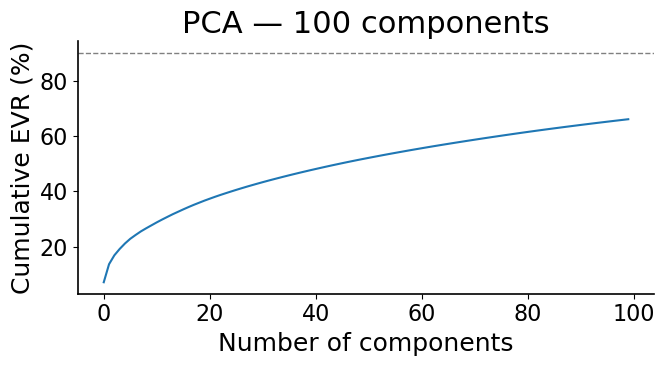

Variance retained: 66.0%


In [11]:
pca = PCA(n_components=N_PCA_COMPONENTS)
pca.fit(anomalies_train)

anomalies_pca_train = pca.transform(anomalies_train)
anomalies_pca_test  = pca.transform(anomalies_test)
anomalies_pca       = pca.transform(anomalies)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.cumsum(pca.explained_variance_ratio_) * 100)
ax.axhline(90, ls="--", color="gray", lw=1)
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative EVR (%)")
ax.set_title(f"PCA — {N_PCA_COMPONENTS} components")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/pca_cumulative_evr.pdf", bbox_inches="tight")
plt.show()

print(f"Variance retained: {np.sum(pca.explained_variance_ratio_)*100:.1f}%")


## 6 — GPCA Fitting Across Candidate Lags
Fit one GPCA model per candidate lag.  For each lag and each value of the
regularisation parameter μ, we record train/test EVR and train/test F-statistic
(Granger causality test).  This is used in §7 to select both the optimal lag
and the optimal μ.


In [12]:
# Storage
gpca_models   = {}   # lag → fitted GrangerPCA
gpca_weights  = {}   # lag → {"weights", "significances", "p-value"}
EVRs_train, EVRs_test     = [], []
F_stats_train, F_stats_test = [], []
FC_train, FC_test           = [], []
SCORES                       = []    # (mu, EVR, F_stat, F_crit) per lag

for lag in tqdm(CANDIDATE_LAGS, desc="Fitting GPCA"):
    evrs_tr, evrs_te = [], []
    Fs_tr,   Fs_te   = [], []
    Fc_tr,   Fc_te   = [], []
    scores           = []

    for mu in MU_GRID:
        gpca_mu = GrangerPCA(
            maxlag=lag,
            method="diff_ratio",
            model_res=RidgeCV(alphas=ALPHA_RIDGE),
            model_full=RidgeCV(alphas=ALPHA_RIDGE),
            alpha=ALPHA_STAB,
            residuals_computation="block_cv",
            block_cv_n_blocks=N_BLOCKS_CV,
            mu=mu, mu_grid=MU_GRID,
            test_level=GC_TEST_LEVEL,
        )
        gpca_mu.fit(oscillation_train[:, None], anomalies_pca_train,
                    plot_lag_analysis=False, verbose=False)

        cp_tr = gpca_mu.transform(anomalies_pca_train)
        cp_te = gpca_mu.transform(anomalies_pca_test)

        w_tr, _ = get_weights(anomalies_pca_train, anomalies_train, gpca_mu)
        w_te, _ = get_weights(anomalies_pca_test,  anomalies_test,  gpca_mu)

        res_tr = test_granger_causality(
            oscillation_train[:, None], cp_tr[:, 0], maxlag=[lag], alpha=ALPHA_STAB)
        res_te = test_granger_causality(
            oscillation_test[:, None],  cp_te[:, 0], maxlag=[lag], alpha=ALPHA_STAB)

        F_tr  = res_tr.loc[res_tr["lag"] == lag, "F_statistic"].values[0]
        Fc_tr_val = res_tr.loc[res_tr["lag"] == lag, "F_critical"].values[0]
        F_te  = res_te.loc[res_te["lag"] == lag, "F_statistic"].values[0]
        Fc_te_val = res_te.loc[res_te["lag"] == lag, "F_critical"].values[0]

        evrs_tr.append(explained_variance_ratio_fast(anomalies_test, np.ravel(w_tr)))
        evrs_te.append(explained_variance_ratio_fast(anomalies_test, np.ravel(w_te)))
        Fs_tr.append(F_tr);  Fc_tr.append(Fc_tr_val)
        Fs_te.append(F_te);  Fc_te.append(Fc_te_val)
        scores.append((mu, evrs_tr[-1], F_tr, Fc_tr_val))

    EVRs_train.append(evrs_tr);  EVRs_test.append(evrs_te)
    F_stats_train.append(Fs_tr); F_stats_test.append(Fs_te)
    FC_train.append(Fc_tr);      FC_test.append(Fc_te)
    SCORES.append(scores)

    # ── Re-fit with optimal μ ───────────────────────────────────────────────
    opt_idx = find_optimal_mu_idx(scores)
    opt_mu  = scores[opt_idx][0]

    gpca_opt = GrangerPCA(
        maxlag=lag,
        method="diff_ratio",
        model_res=RidgeCV(alphas=ALPHA_RIDGE),
        model_full=RidgeCV(alphas=ALPHA_RIDGE),
        alpha=ALPHA_STAB,
        residuals_computation="block_cv",
        block_cv_n_blocks=N_BLOCKS_CV,
        mu=opt_mu, mu_grid=MU_GRID,
        test_level=GC_TEST_LEVEL,
    )
    gpca_opt.fit(oscillation_train[:, None], anomalies_pca_train,
                 plot_lag_analysis=False, verbose=False)

    w_all, sig_all = get_weights(anomalies_pca, anomalies, gpca_opt)

    cp_test_opt = gpca_opt.transform(anomalies_pca_test)
    res_opt = test_granger_causality(
        oscillation_test[:, None], cp_test_opt[:, 0], maxlag=[lag])

    gpca_models[lag]  = gpca_opt
    gpca_weights[lag] = {
        "weights":       np.ravel(w_all),
        "significances": sig_all,
        "p-value":       res_opt.loc[res_opt["lag"] == lag, "p_value"].values[0],
        "mu":            opt_mu,
        "EVR_test":      evrs_te[opt_idx],
        "F_test":        Fs_te[opt_idx],
    }

    print(f"Lag {lag}:  optimal μ = {opt_mu:.2e}  |  "
          f"EVR_test = {evrs_te[opt_idx]:.4f}  |  "
          f"F_test = {Fs_te[opt_idx]:.3f}  |  "
          f"p = {gpca_weights[lag]['p-value']:.3e}")


Fitting GPCA:   0%|          | 0/4 [00:00<?, ?it/s]

Fitting GPCA:  25%|██▌       | 1/4 [01:00<03:01, 60.60s/it]

Lag 1:  optimal μ = 2.29e-02  |  EVR_test = 0.0821  |  F_test = 8.534  |  p = 4.418e-03


Fitting GPCA:  50%|█████     | 2/4 [02:51<03:00, 90.45s/it]

Lag 2:  optimal μ = 5.88e-02  |  EVR_test = 0.0820  |  F_test = 4.350  |  p = 1.586e-02


Fitting GPCA:  75%|███████▌  | 3/4 [03:58<01:19, 79.48s/it]

Lag 3:  optimal μ = 3.67e-02  |  EVR_test = 0.0823  |  F_test = 3.181  |  p = 2.815e-02


Fitting GPCA: 100%|██████████| 4/4 [05:31<00:00, 82.82s/it]

Lag 4:  optimal μ = 3.67e-02  |  EVR_test = 0.0833  |  F_test = 2.731  |  p = 3.471e-02


## 7 — Optimal Lag Selection
Choose the lag that achieves the highest test EVR **and** whose Granger
causality p-value is below `PVALUE_THRESHOLD`.


In [13]:
# Candidate lags that pass the significance threshold
eligible = {
    lag: info
    for lag, info in gpca_weights.items()
    if info["p-value"] < PVALUE_THRESHOLD
}

if eligible:
    optimal_lag = max(eligible, key=lambda l: eligible[l]["EVR_test"])
    print(f"Eligible lags: {list(eligible.keys())}")
    print(f"Optimal lag  : {optimal_lag}  "
          f"(EVR = {eligible[optimal_lag]['EVR_test']:.4f}, "
          f"p = {eligible[optimal_lag]['p-value']:.3e})")
else:
    # Fallback: lag with smallest p-value
    optimal_lag = min(gpca_weights, key=lambda l: gpca_weights[l]["p-value"])
    print(f"No lag passed p < {PVALUE_THRESHOLD}. "
          f"Using lag {optimal_lag} (smallest p).")

gpca_best = gpca_models[optimal_lag]
best_info = gpca_weights[optimal_lag]


Eligible lags: [1, 2, 3, 4]
Optimal lag  : 4  (EVR = 0.0833, p = 3.471e-02)


## 8 — Baseline Comparisons
Fit all baseline teleconnection methods at the optimal lag.


In [14]:
ca  = CompositeAnalysis(maxlag=optimal_lag)
ra  = RegressionAnalysis(maxlag=optimal_lag)
cca = CanonicalCorrelationAnalysis(maxlag=optimal_lag, n_components=1)
sa  = SpatialAveraging()
pc  = PrincipalComponents()

ca.fit(oscillation_train[:, None],  anomalies_pca_train)
ra.fit(oscillation_train[:, None],  anomalies_pca_train)
cca.fit(oscillation_train[:, None], anomalies_pca_train)
sa.fit(oscillation_train[:, None],  anomalies_train)
pc.fit(oscillation_train[:, None],  anomalies_train)

cp_test_ca  = ca.transform(anomalies_pca_test, type="PosNeg")
cp_test_ra  = ra.transform(anomalies_pca_test)
cp_test_cca = cca.transform(anomalies_pca_test)
cp_test_sa  = sa.transform(anomalies_test)
cp_test_pc  = pc.transform(anomalies_test)
cp_test_gpca = gpca_best.transform(anomalies_pca_test)

# Spatial correlation weights (full dataset)
corr_ca,  sig_ca  = get_weights(anomalies_pca, anomalies, ca)
corr_ra,  sig_ra  = get_weights(anomalies_pca, anomalies, ra)
corr_cca, sig_cca = get_weights(anomalies_pca, anomalies, cca)
corr_sa,  sig_sa  = get_weights(anomalies,     anomalies, sa)
corr_pc,  sig_pc  = get_weights(anomalies,     anomalies, pc)

print("Baseline models fitted.")


Baseline models fitted.


## 9 — Results: Granger Causality & EVR Summary Table

In [15]:
lags_test = [optimal_lag]

res_gpca = test_granger_causality(oscillation_test[:, None], cp_test_gpca[:, 0], maxlag=lags_test)
res_ca   = test_granger_causality(oscillation_test[:, None], cp_test_ca,          maxlag=lags_test)
res_ra   = test_granger_causality(oscillation_test[:, None], cp_test_ra,          maxlag=lags_test)
res_cca  = test_granger_causality(oscillation_test[:, None], cp_test_cca,         maxlag=lags_test)
res_sa   = test_granger_causality(oscillation_test[:, None], cp_test_sa,          maxlag=lags_test)
res_pc   = test_granger_causality(oscillation_test[:, None], cp_test_pc,          maxlag=lags_test)

w_gpca = best_info["weights"]
w_ca   = np.ravel(corr_ca);  w_ra  = np.ravel(corr_ra)
w_cca  = np.ravel(corr_cca); w_sa  = np.ravel(corr_sa)
w_pc   = np.ravel(corr_pc)

method_dict = {
    "GPCA":           (res_gpca, explained_variance_ratio_fast(anomalies_test, w_gpca)),
    "CCA":            (res_cca,  explained_variance_ratio_fast(anomalies_test, w_cca)),
    "Composites":     (res_ca,   explained_variance_ratio_fast(anomalies_test, w_ca)),
    "Regression":     (res_ra,   explained_variance_ratio_fast(anomalies_test, w_ra)),
    "Spatial Avg":    (res_sa,   explained_variance_ratio_fast(anomalies_test, w_sa)),
    "PCA":            (res_pc,   explained_variance_ratio_fast(anomalies_test, w_pc)),
}

results_table = build_results_table(method_dict, optimal_lag)
display(results_table.style.format({"EVR": "{:.4f}", "F_statistic": "{:.3f}", "p_value": "{:.3e}"}))


,Method,EVR,F_statistic,p_value
0,GPCA,0.0494,2.731,3.471e-02
1,CCA,0.0462,3.619,9.200e-03
2,Composites,0.0433,3.637,8.949e-03
3,Regression,0.0426,3.894,6.108e-03
4,Spatial Avg,0.0634,0.565,6.887e-01
5,PCA,0.0497,1.986,1.046e-01


In [16]:
# Save LaTeX table
latex_str = results_table.to_latex(
    index=False, float_format="%.4f",
    caption=f"Granger causality and EVR comparison at lag = {optimal_lag}",
    label="tab:results_comparison",
    escape=True,
)
with open(f"../tables/results_lag{optimal_lag}.tex", "w") as f:
    f.write(latex_str)
print("LaTeX table saved.")


LaTeX table saved.


## 10 — Spatial Weight Maps

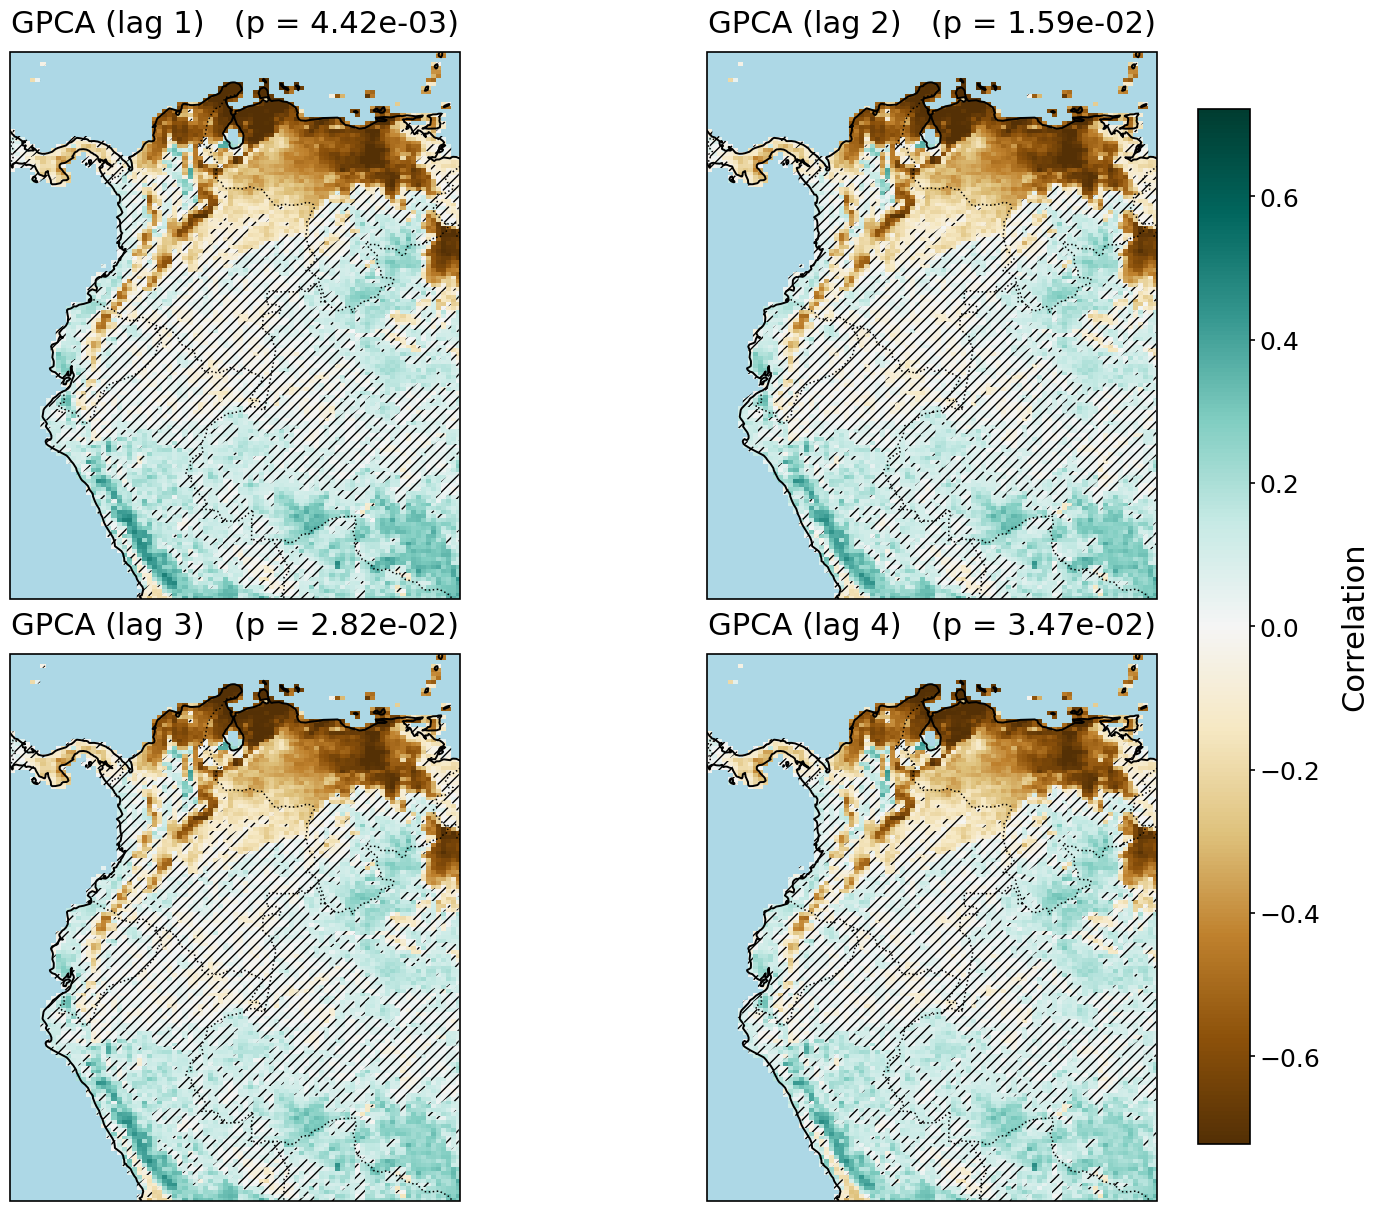

In [17]:
weight_maps = {
    f"GPCA (lag {lag})": {
        "weights":       gpca_weights[lag]["weights"],
        "significances": gpca_weights[lag]["significances"],
        "p-value":       [gpca_weights[lag]["p-value"]],
    }
    for lag in CANDIDATE_LAGS
}

path_weights = f"../figures/weight_maps_NDVI_NSA_lags{'_'.join(map(str, CANDIDATE_LAGS))}.pdf"
plot_weight_maps(
    weight_maps, "ndvi",
    extent=EXTENT,
    easting=easting, northing=northing,
    save_path=path_weights,
    na_mask=na_mask,
    cmap="BrBG",
)


## 11 — μ Regularisation: EVR vs Granger Causality Trade-off
Shows how the optimal μ chosen on the training set transfers to the test set.
Each point on a curve corresponds to one value of μ; the arrow direction
indicates increasing μ.  The optimal point (▪ train, ● test) is highlighted.


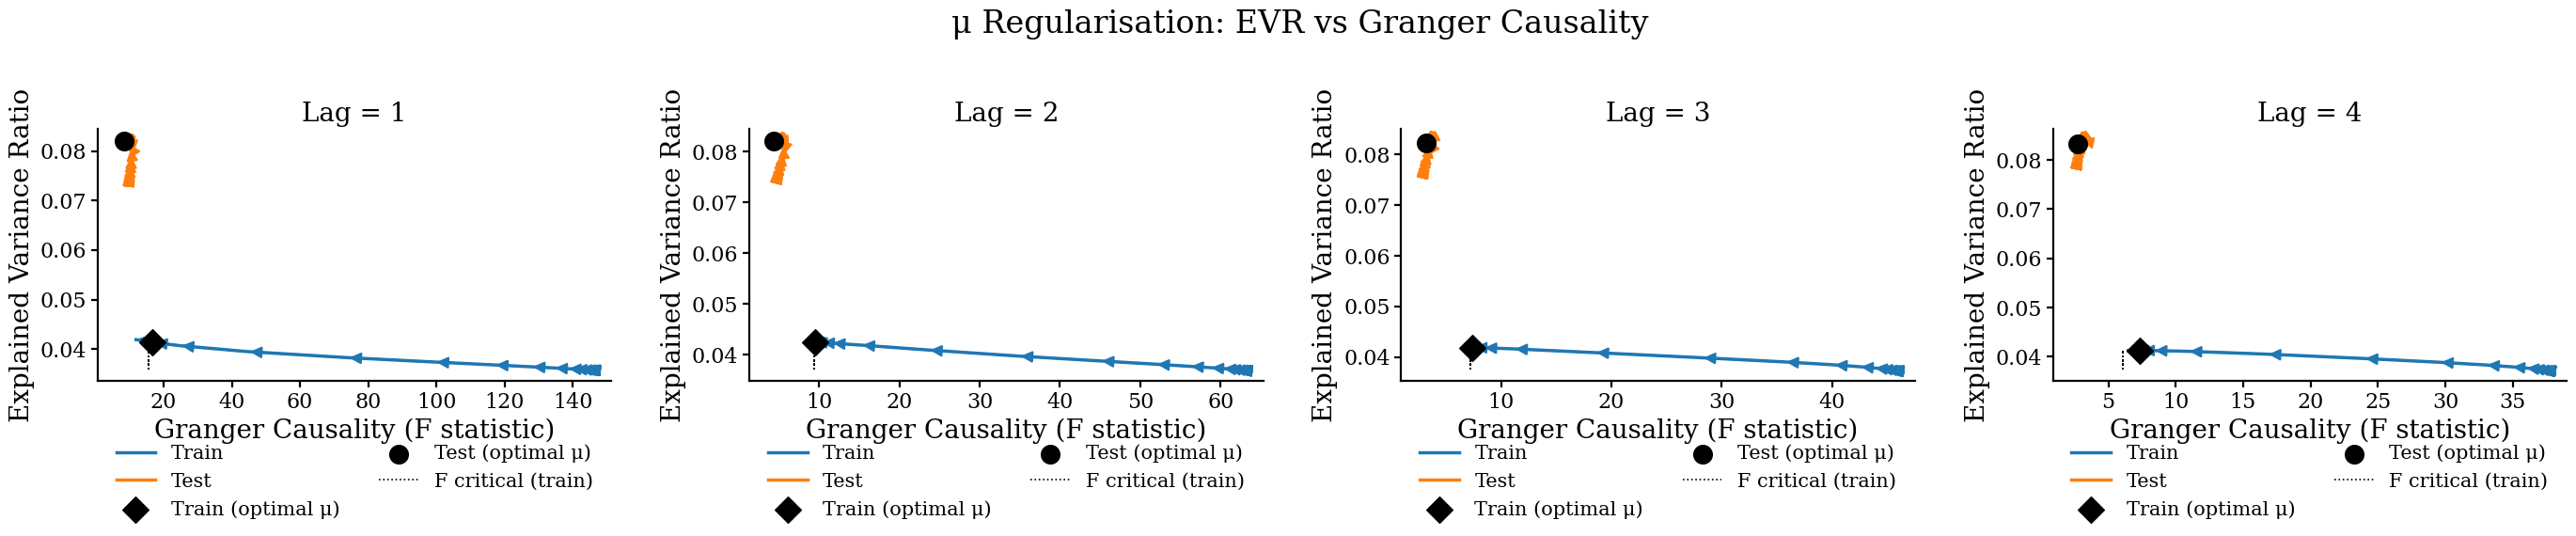

In [18]:
pub_rc = {
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "font.size": 18, "axes.labelsize": 20, "axes.titlesize": 20,
    "xtick.labelsize": 16, "ytick.labelsize": 16, "legend.fontsize": 15,
    "axes.linewidth": 1.6, "lines.linewidth": 2.5,
    "xtick.major.width": 1.6, "ytick.major.width": 1.6,
    "xtick.major.size": 5,  "ytick.major.size": 5,
    "pdf.fonttype": 42, "ps.fonttype": 42,
}

with mpl.rc_context(pub_rc):
    n_lags = len(CANDIDATE_LAGS)
    fig, axes = plt.subplots(1, n_lags, figsize=(7 * n_lags, 6),
                             sharey=False, sharex=False)
    if n_lags == 1:
        axes = [axes]

    for ax, lag_idx, lag in zip(axes, range(n_lags), CANDIDATE_LAGS):
        x_tr = np.array(F_stats_train[lag_idx])
        y_tr = np.array(EVRs_train[lag_idx])
        x_te = np.array(F_stats_test[lag_idx])
        y_te = np.array(EVRs_test[lag_idx])

        l_tr, = ax.plot(x_tr, y_tr, color="tab:blue",  label="Train")
        l_te, = ax.plot(x_te, y_te, color="tab:orange", label="Test")

        # Direction arrows
        for x, y, color in [(x_tr, y_tr, "tab:blue"), (x_te, y_te, "tab:orange")]:
            for i in range(len(x) - 1):
                ax.annotate("",
                    xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                    arrowprops=dict(arrowstyle="-|>", lw=1.6, color=color))

        # Optimal point
        opt_idx = find_optimal_mu_idx(SCORES[lag_idx])
        ax.scatter(x_tr[opt_idx], y_tr[opt_idx], s=200, marker="D",
                   color="black", zorder=6, label="Train (optimal μ)")
        ax.scatter(x_te[opt_idx], y_te[opt_idx], s=200, marker="o",
                   color="black", zorder=6, label="Test (optimal μ)")

        # F-critical line
        Fc_arr = np.array(FC_train[lag_idx])
        ymin, ymax = y_tr.min(), y_tr.max()
        ax.vlines(Fc_arr, ymin, ymax, linestyles=":", colors="black",
                  lw=1.2, label="F critical (train)")

        ax.set_xlabel("Granger Causality (F statistic)")
        ax.set_ylabel("Explained Variance Ratio")
        ax.set_title(f"Lag = {lag}")
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18),
                  ncol=2, frameon=False)

    fig.suptitle("μ Regularisation: EVR vs Granger Causality", y=1.02)
    plt.tight_layout()
    plt.savefig("../figures/mu_tradeoff_EVR_GC.pdf", dpi=300, bbox_inches="tight")
    plt.show()


## 12 — Final Composite Figure (Nature Communications)

> **Figure caption:**
> **(A)** NSA climate zones following the Köppen-Geiger classification.
> **(B)** GPCA spatial patterns indicating the Granger-causal influence of ENSO on NDVI.
> **(C)** Selection of the PCA regularisation parameter μ, demonstrating the trade-off
> between explained variance ratio (EVR) and Granger causality (GC) significance.
> **(D)** Seasonal phasing of ENSO peaks relative to the northern and southern tropical
> wet seasons.
> **(E)** Correlation between GPCA components and NDVI across different climate zones
> and hemispheres, highlighting the Aw divergence.


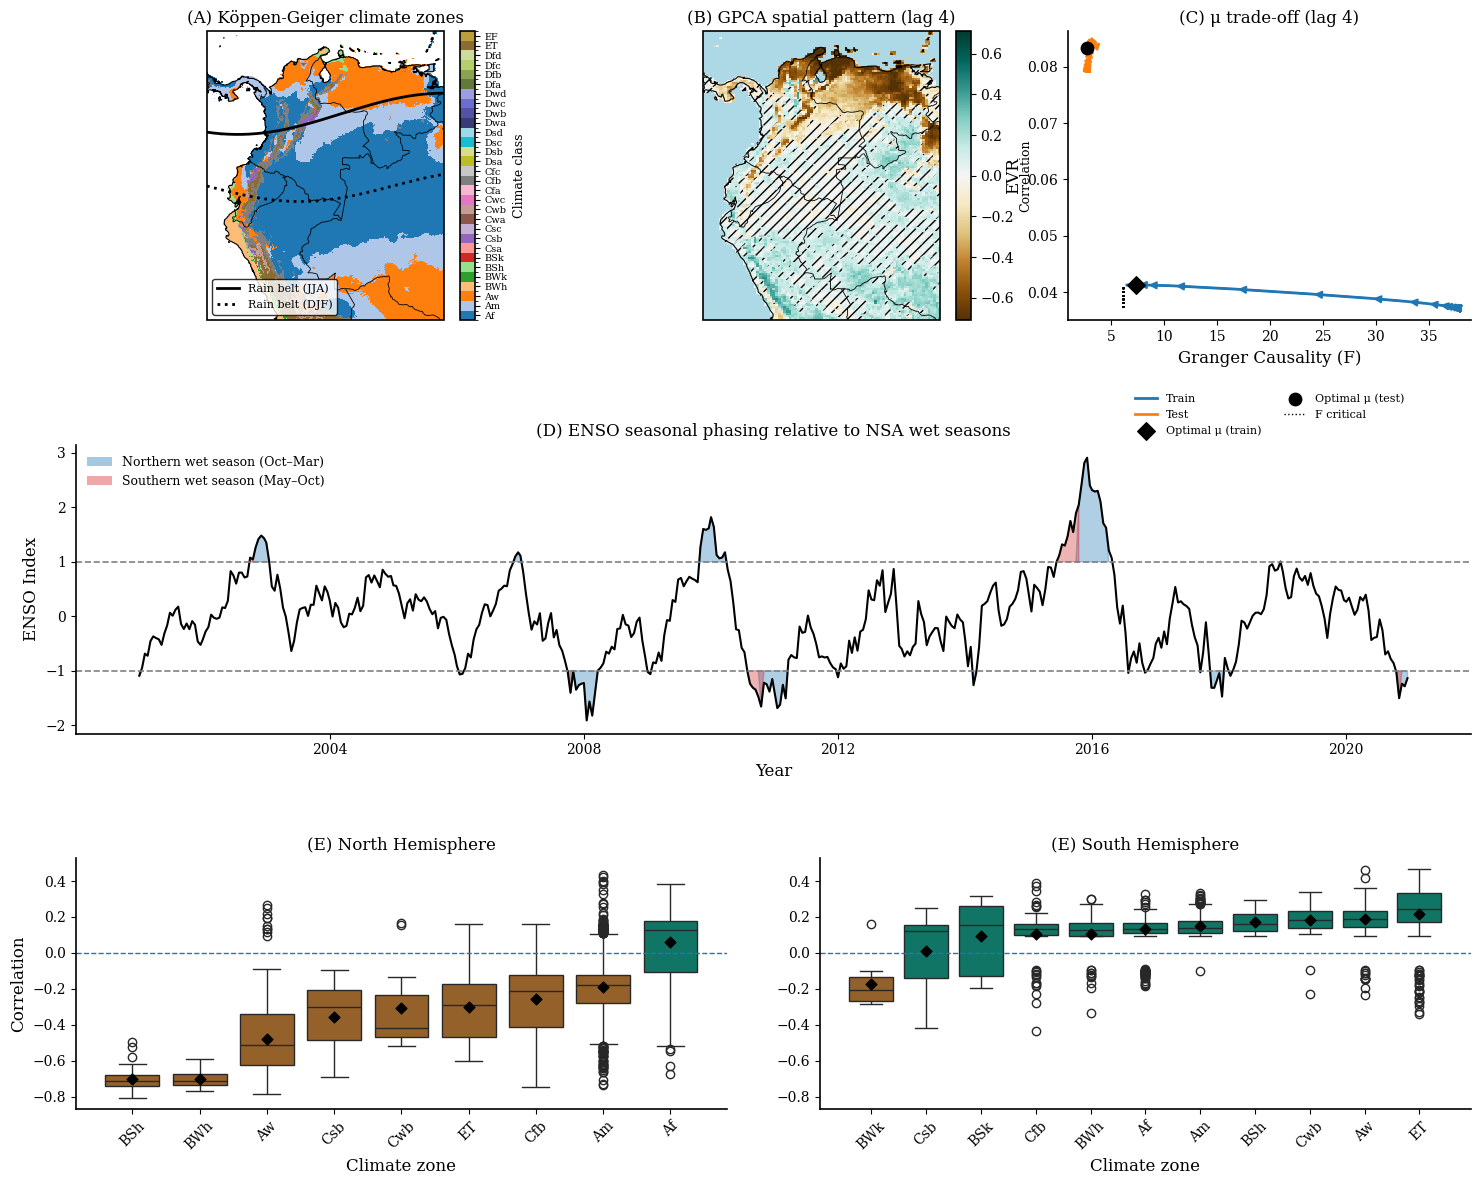

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
import seaborn as sns
from matplotlib.patches import Patch

lon2d, lat2d = build_lonlat_grid(easting, northing)

with rasterio.open(KOPPEN_TIF) as src:
    climate      = src.read(1).astype(float)
    clim_tr      = src.transform
    nodata       = src.nodata
if nodata is not None:
    climate[climate == nodata] = np.nan

unique_cls = np.unique(climate)
unique_cls = unique_cls[unique_cls > 0].astype(int)

tab_colors = (
    list(plt.get_cmap("tab20").colors) +
    list(plt.get_cmap("tab20b").colors) +
    list(plt.get_cmap("tab20c").colors)
)[:len(unique_cls)]
cmap_kg  = mcolors.ListedColormap(tab_colors)
bounds_kg = np.arange(unique_cls.min(), unique_cls.max() + 2)
norm_kg  = mcolors.BoundaryNorm(bounds_kg, cmap_kg.N)

w_best   = best_info["weights"]
sig_best = best_info["significances"]
w2d      = reconstruct_2d_field(w_best, na_mask)
sig2d    = reconstruct_2d_field(sig_best.astype(float), na_mask, fill=0).astype(bool)

vmax_w = np.nanpercentile(np.abs(w2d), 99)
norm_w = mcolors.TwoSlopeNorm(vmin=-vmax_w, vcenter=0, vmax=vmax_w)

lag_idx_best = CANDIDATE_LAGS.index(optimal_lag)
x_tr = np.array(F_stats_train[lag_idx_best])
y_tr = np.array(EVRs_train[lag_idx_best])
x_te = np.array(F_stats_test[lag_idx_best])
y_te = np.array(EVRs_test[lag_idx_best])
opt_idx_best = find_optimal_mu_idx(SCORES[lag_idx_best])

df_kp = build_koppen_dataframe(w2d, sig2d, lon2d, lat2d, KOPPEN_TIF)

NAT_RC = {
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "font.size": 11, "axes.labelsize": 12, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "axes.linewidth": 1.2, "lines.linewidth": 1.8,
    "pdf.fonttype": 42, "ps.fonttype": 42,
}

with mpl.rc_context(NAT_RC):
    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(
        3, 6,
        figure=fig,
        height_ratios=[1.15, 1.15, 1.0],
        hspace=0.45, wspace=0.6,
    )

    ax_A = fig.add_subplot(gs[0, 0:2], projection=ccrs.PlateCarree())
    ax_A.set_extent(EXTENT, crs=ccrs.PlateCarree())
    ax_A.imshow(
        climate,
        origin="upper",
        extent=[
            clim_tr.c,
            clim_tr.c + clim_tr.a * climate.shape[1],
            clim_tr.f + clim_tr.e * climate.shape[0],
            clim_tr.f,
        ],
        transform=ccrs.PlateCarree(),
        cmap=cmap_kg, norm=norm_kg, interpolation="nearest",
    )
    lon_line = np.linspace(EXTENT[0], EXTENT[1], 400)
    ax_A.plot(lon_line, 6 + 2 * np.sin((lon_line + 70) * np.pi / 20),
              color="black", lw=2.0, ls="-",  label="Rain belt (JJA)",
              transform=ccrs.PlateCarree())
    ax_A.plot(lon_line, -1 + 1.5 * np.sin((lon_line + 65) * np.pi / 18),
              color="black", lw=2.0, ls=":",  label="Rain belt (DJF)",
              transform=ccrs.PlateCarree())
    ax_A.legend(fontsize=8, frameon=True, edgecolor="black", loc="lower left")
    ax_A.coastlines(resolution="10m", lw=0.8)
    ax_A.add_feature(cfeature.BORDERS, lw=0.6)
    cbar_A = plt.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap_kg, norm=norm_kg),
        ax=ax_A, orientation="vertical", fraction=0.046, pad=0.04,
    )
    cbar_A.set_ticks(unique_cls + 0.5)
    cbar_A.set_ticklabels([KOPPEN_NAMES.get(c, str(c)) for c in unique_cls], fontsize=7)
    cbar_A.set_label("Climate class", fontsize=9)
    ax_A.set_title("(A) Köppen-Geiger climate zones")

    ax_B = fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree())
    ax_B.set_extent(EXTENT, crs=ccrs.PlateCarree())
    pm = ax_B.pcolormesh(
        lon2d, lat2d, w2d,
        cmap="BrBG", norm=norm_w, shading="auto",
        transform=ccrs.PlateCarree(), zorder=1,
    )
    nonsig = (~sig2d) & np.isfinite(w2d)
    if np.any(nonsig):
        ax_B.contourf(lon2d, lat2d, nonsig.astype(float),
                      levels=[0.5, 1], colors="none",
                      hatches=["///"], transform=ccrs.PlateCarree(), zorder=3)
    ax_B.coastlines(lw=0.8)
    ax_B.add_feature(cfeature.BORDERS, lw=0.6)
    ax_B.add_feature(cfeature.LAND,  facecolor="lightgray")
    ax_B.add_feature(cfeature.OCEAN, facecolor="lightblue")
    cbar_B = plt.colorbar(pm, ax=ax_B, orientation="vertical", fraction=0.046, pad=0.04)
    cbar_B.set_label("Correlation", fontsize=9)
    ax_B.set_title(f"(B) GPCA spatial pattern (lag {optimal_lag})")

    ax_C = fig.add_subplot(gs[0, 4:6])
    ax_C.plot(x_tr, y_tr, color="tab:blue",  lw=2, label="Train")
    ax_C.plot(x_te, y_te, color="tab:orange", lw=2, label="Test")
    for x, y, c in [(x_tr, y_tr, "tab:blue"), (x_te, y_te, "tab:orange")]:
        for i in range(len(x) - 1):
            ax_C.annotate("", xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                arrowprops=dict(arrowstyle="-|>", lw=1.4, color=c))
    ax_C.scatter(x_tr[opt_idx_best], y_tr[opt_idx_best], s=80, marker="D", color="black", zorder=6, label="Optimal μ (train)")
    ax_C.scatter(x_te[opt_idx_best], y_te[opt_idx_best], s=80, marker="o", color="black", zorder=6, label="Optimal μ (test)")
    ax_C.vlines(np.array(FC_train[lag_idx_best]), y_tr.min(), y_tr.max(), ls=":", colors="black", lw=1.0, label="F critical")
    ax_C.set_xlabel("Granger Causality (F)")
    ax_C.set_ylabel("EVR")
    ax_C.set_title(f"(C) μ trade-off (lag {optimal_lag})")
    ax_C.spines[["top", "right"]].set_visible(False)
    ax_C.legend(fontsize=8, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)

    ax_D = fig.add_subplot(gs[1, :])
    df_D = pd.DataFrame({"oscillation": oscillation}, index=pd.to_datetime(dates))
    
    idx_dt = df_D.index
    n_wet = (idx_dt.month >= 10) | (idx_dt.month <= 3)
    s_wet = (idx_dt.month >= 5) & (idx_dt.month <= 10)
    el_n  = (df_D["oscillation"] > 1).values
    la_n  = (df_D["oscillation"] < -1).values

    ax_D.plot(df_D.index, df_D["oscillation"], color="black", lw=1.5)
    ax_D.axhline( 1, ls="--", color="gray", lw=1.2)
    ax_D.axhline(-1, ls="--", color="gray", lw=1.2)

    for cond, base, col in [
        (el_n & n_wet,  1, "#1f77b4"), (el_n & s_wet,  1, "#d62728"),
        (la_n & n_wet, -1, "#1f77b4"), (la_n & s_wet, -1, "#d62728"),
    ]:
        ax_D.fill_between(df_D.index, base, df_D["oscillation"].values,
                          where=cond, interpolate=True, color=col, alpha=0.35)

    ax_D.set_ylabel("ENSO Index")
    ax_D.set_xlabel("Year")
    ax_D.spines[["top", "right"]].set_visible(False)
    ax_D.legend(
        handles=[
            Patch(facecolor="#1f77b4", alpha=0.4, label="Northern wet season (Oct–Mar)"),
            Patch(facecolor="#d62728", alpha=0.4, label="Southern wet season (May–Oct)"),
        ],
        frameon=False, loc="upper left", fontsize=9,
    )
    ax_D.set_title("(D) ENSO seasonal phasing relative to NSA wet seasons")

    ax_E_N = fig.add_subplot(gs[2, 0:3])
    ax_E_S = fig.add_subplot(gs[2, 3:6], sharey=ax_E_N)

    for ax_e, hemi, title_h in zip([ax_E_N, ax_E_S], ["North", "South"], ["(E) North Hemisphere", "(E) South Hemisphere"]):
        sub = df_kp[df_kp["hemisphere"] == hemi]
        if sub.empty:
            ax_e.set_visible(False)
            continue
        means = sub.groupby("climate")["correlation"].mean()
        order = means.sort_values().index.tolist()
        palette = {cl: ("#A6611A" if means[cl] < 0 else "#018571") for cl in means.index}
        sns.boxplot(data=sub, x="climate", y="correlation", order=order, hue="climate", palette=palette, legend=False, ax=ax_e, linewidth=1.0)
        ax_e.scatter(range(len(order)), means.loc[order].values, marker="D", s=30, color="black", zorder=4)
        ax_e.axhline(0, ls="--", lw=1)
        ax_e.set_xlabel("Climate zone")
        ax_e.set_ylabel("Correlation" if hemi == "North" else "")
        ax_e.tick_params(axis="x", rotation=45)
        ax_e.spines[["top", "right"]].set_visible(False)
        ax_e.set_title(title_h)

    plt.savefig("../figures/NSA_analysis_NatComm.pdf", dpi=300, bbox_inches="tight")
    plt.savefig("../figures/NSA_analysis_NatComm.png", dpi=300, bbox_inches="tight")
    plt.show()